In [2]:
import numpy as np

def calculate_elo(models, win_matrix, anchor_index=0, initial_elo=1000, iterations=50000, lr=5.0):
    """
    Calculates relative Elo scores from a partially filled win rate matrix.
    
    :param models: List of model names/versions.
    :param win_matrix: NxN numpy array of win rates (0.0 to 1.0). Use np.nan for missing data.
    :param anchor_index: The index of the model to pin to the initial_elo.
    :param initial_elo: The baseline Elo score (usually 1000 for model 0).
    :param iterations: Number of optimization steps.
    :param lr: Learning rate for gradient descent.
    """
    n = len(models)
    ratings = np.ones(n) * initial_elo
    
    # Clip win rates slightly to prevent 100% or 0% from pushing Elo to infinity
    # A 99% win rate represents an Elo difference of roughly ~800 points.
    win_matrix = np.clip(win_matrix, 0.01, 0.99)

    print("Optimizing Elo ratings...\n")
    for _ in range(iterations):
        gradients = np.zeros(n)
        
        for i in range(n):
            for j in range(n):
                # Skip self-play and missing data
                if i == j or np.isnan(win_matrix[i, j]):
                    continue
                
                actual_win_rate = win_matrix[i, j]
                
                # Expected win rate based on current Elo estimates
                # Standard Elo formula: E_A = 1 / (1 + 10^((R_B - R_A) / 400))
                expected_win_rate = 1.0 / (1.0 + 10 ** ((ratings[j] - ratings[i]) / 400.0))
                
                # Gradient update: If model won more than expected, increase its Elo.
                gradients[i] += (actual_win_rate - expected_win_rate)
        
        ratings += lr * gradients
        
        # Anchor the baseline model (Model 0) to prevent the whole scale from drifting
        offset = initial_elo - ratings[anchor_index]
        ratings += offset
        
    return ratings

# ==========================================
# 1. Setup your Models
# ==========================================
models = [0, 50, 100, 200, 400, 600, 800, 1000]
N = len(models)

# Initialize the matrix with NaN to represent missing data
win_matrix = np.full((N, N), np.nan)

def add_matchup(model_a, model_b, tournament_point):
    """Helper function to cleanly input data."""
    score = (tournament_point+1)/2
    idx_a = models.index(model_a)
    idx_b = models.index(model_b)
    
    # a_(i,j) + a_(j,i) = 1.0
    win_matrix[idx_a, idx_b] = score
    win_matrix[idx_b, idx_a] = 1.0 - score

In [3]:
# ==========================================
# 2. Input your Win Rates (0.0 to 1.0)
# ==========================================
add_matchup(50, 000, 0.4359)
add_matchup(100, 000, 0.5828)
add_matchup(200, 000, 0.6617)
add_matchup(400, 000, 0.6461)
add_matchup(600, 000, 0.6445)
add_matchup(800, 000, 0.6641)

add_matchup(100, 50, 0.1211)
add_matchup(200, 50, .3164)
add_matchup(400, 50, 0.3164)

add_matchup(200, 100, 0.1797)
add_matchup(400, 100, 0.2133)

add_matchup(400, 200, 0.0992)
add_matchup(600, 200, 0.1156)
add_matchup(800, 200, 0.1633)
add_matchup(1000, 200, 0.1531)

add_matchup(600, 400, 0.0109)
add_matchup(800, 400, 0.0813)
add_matchup(1000, 400,  0.1102)

add_matchup(800, 600, 0.0508)
add_matchup(1000, 600, 0.0414)

add_matchup(1000, 800,  0.0391)


In [4]:
# ==========================================
# 3. Calculate and Print
# ==========================================
final_elos = calculate_elo(models, win_matrix, anchor_index=0, initial_elo=1000)

print("=== FINAL RELATIVE ELO SCORES ===")
for i in range(N):
    print(f"Model {models[i]:>3}: {final_elos[i]:>6.1f} Elo")

Optimizing Elo ratings...

=== FINAL RELATIVE ELO SCORES ===
Model   0: 1000.0 Elo
Model  50: 1158.5 Elo
Model 100: 1205.7 Elo
Model 200: 1257.7 Elo
Model 400: 1278.5 Elo
Model 600: 1287.7 Elo
Model 800: 1302.9 Elo
Model 1000: 1311.7 Elo


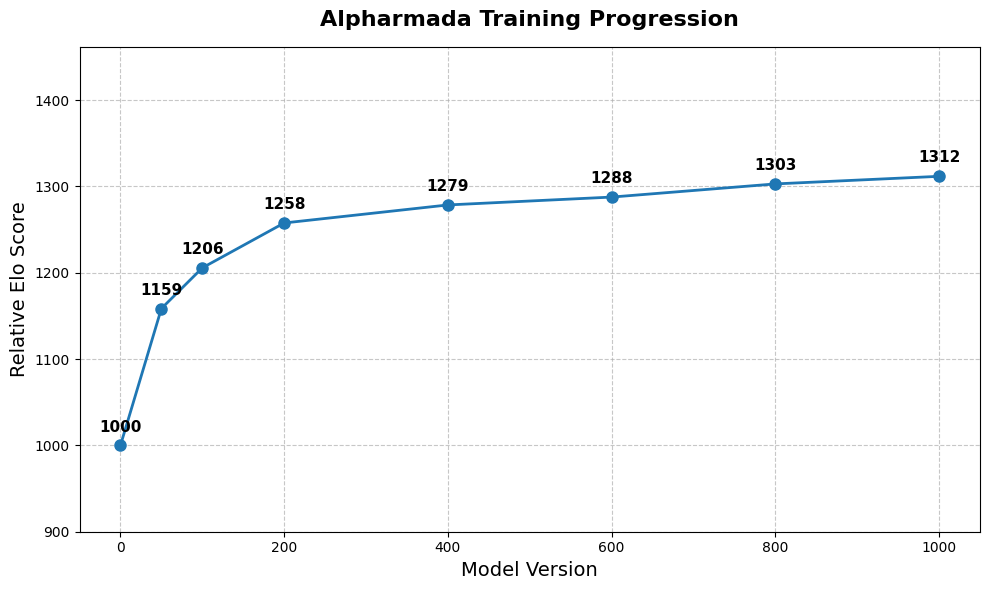

In [5]:
import matplotlib.pyplot as plt

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the data: Model versions on X-axis, Elo scores on Y-axis
plt.plot(models, final_elos, marker='o', linestyle='-', color='#1f77b4', markersize=8, linewidth=2)

# Add titles and labels
plt.title('Alpharmada Training Progression', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Model Version', fontsize=14)
plt.ylabel('Relative Elo Score', fontsize=14)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate each data point with its exact Elo score
for i, elo in enumerate(final_elos):
    plt.annotate(f'{elo:.0f}', 
                 (models[i], final_elos[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=11,
                 fontweight='bold')

# Ensure the y-axis has a bit of padding at the top and bottom
y_min, y_max = min(final_elos), max(final_elos)
plt.ylim(y_min - 100, y_max + 150)

# Render the graph
plt.tight_layout()
plt.show()